Week 10 Challenge
Task 1: Brent Oil Price Analysis
1. Import Libraries


In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.style.use("ggplot")

print("Libraries imported successfully.")

Libraries imported successfully.


2. Load the Dataset

In [4]:
# Load Brent Oil Prices dataset

df = pd.read_csv("../data/raw/BrentOilPrices.csv")

df.head()

,Date,Price
0,20-May-87,18.63
1,21-May-87,18.45
2,22-May-87,18.55
3,25-May-87,18.60
4,26-May-87,18.63


In [5]:
# Display dataset shape

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 9011
Columns: 2
<class 'pandas.DataFrame'>
RangeIndex: 9011 entries, 0 to 9010
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    9011 non-null   str    
 1   Price   9011 non-null   float64
dtypes: float64(1), str(1)
memory usage: 140.9 KB


3. Data Cleaning

In [6]:
# Convert Date column

df["Date"] = pd.to_datetime(df["Date"])

# Sort data

df = df.sort_values("Date")

# Reset index

df.reset_index(drop=True, inplace=True)

df.head()

,Date,Price
0,1987-05-20,18.63
1,1987-05-21,18.45
2,1987-05-22,18.55
3,1987-05-25,18.60
4,1987-05-26,18.63


In [7]:
# Missing values

df.isnull().sum()

Date     0
Price    0
dtype: int64

In [9]:
# Check duplicates

df.duplicated().sum()

np.int64(0)

In [10]:
# Summary statistics

df.describe()

,Date,Price
count,9011,9011.000000
mean,2005-02-10 23:46:53.760958,48.420782
min,1987-05-20 00:00:00,9.100000
25%,1996-03-20 12:00:00,19.050000
50%,2005-02-02 00:00:00,38.570000
75%,2014-01-09 12:00:00,70.090000
max,2022-11-14 00:00:00,143.950000
std,NaN,32.860110


4. Price Trend Visualization

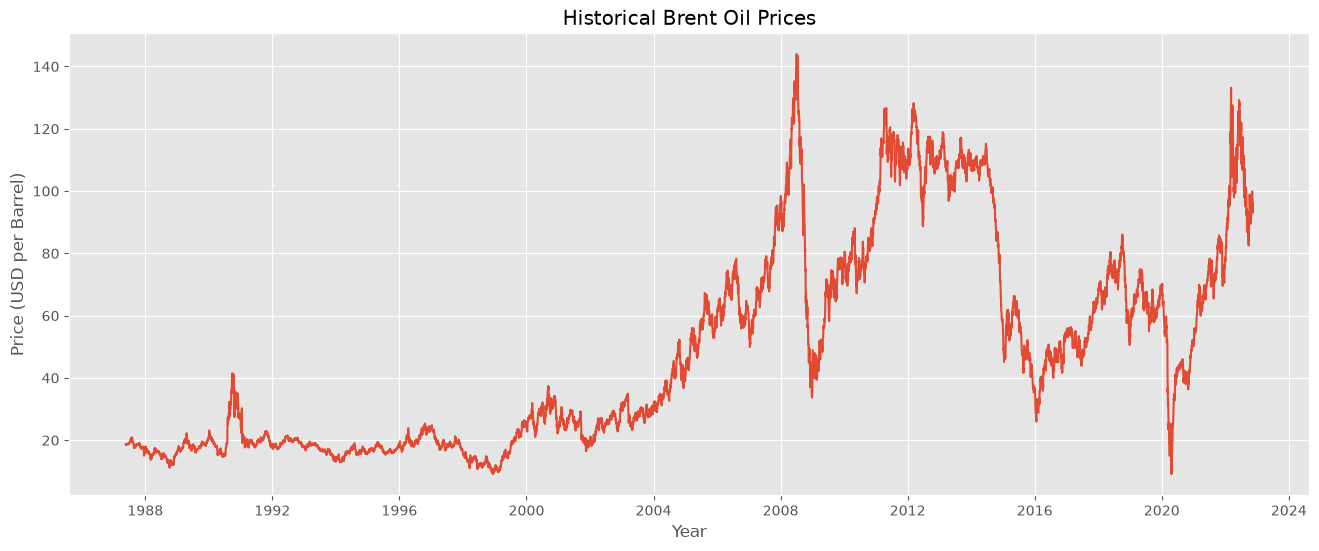

In [11]:
plt.figure(figsize=(16,6))

plt.plot(df["Date"], df["Price"])

plt.title("Historical Brent Oil Prices")

plt.xlabel("Year")

plt.ylabel("Price (USD per Barrel)")

plt.show()

### Interpretation

The historical Brent oil price series exhibits significant fluctuations over the period from 1987 to 2022, indicating that the oil market has experienced multiple periods of stability and volatility.

**Key observations:**

- **1987–1999:** Oil prices remained relatively low and stable, generally fluctuating between **$10 and $30 per barrel**, with only a few short-term spikes.
- **2000–2008:** A strong upward trend is observed, with prices rising steadily and reaching a historical peak of approximately **$145 per barrel** in 2008. This increase reflects growing global demand and supply constraints before the global financial crisis.
- **Late 2008–2009:** A sharp decline follows the 2008 peak, where prices dropped to around **$35–40 per barrel**, indicating the significant impact of the global financial crisis on oil demand.
- **2011–2014:** Prices recovered and remained relatively high, mostly above **$100 per barrel**, suggesting a period of sustained market strength.
- **2014–2016:** Another substantial decline occurred, with prices falling below **$30 per barrel**, likely associated with increased oil production and changes in OPEC production policies.
- **2020:** The most dramatic price drop is observed during the COVID-19 pandemic, reflecting the collapse in global oil demand due to travel restrictions and economic shutdowns.
- **2021–2022:** Prices recovered rapidly and exceeded **$120 per barrel**, coinciding with post-pandemic economic recovery and geopolitical tensions, particularly the Russia–Ukraine conflict.

### Conclusion

The visualization clearly indicates that Brent oil prices are **non-stationary**, exhibiting changing mean levels, long-term trends, and periods of high volatility. Several abrupt structural changes are visible throughout the series, suggesting the presence of potential **change points** associated with major geopolitical and economic events. These observations support the use of **Bayesian Change Point Analysis** in the subsequent stages of the project to formally identify and quantify structural breaks in the time series.

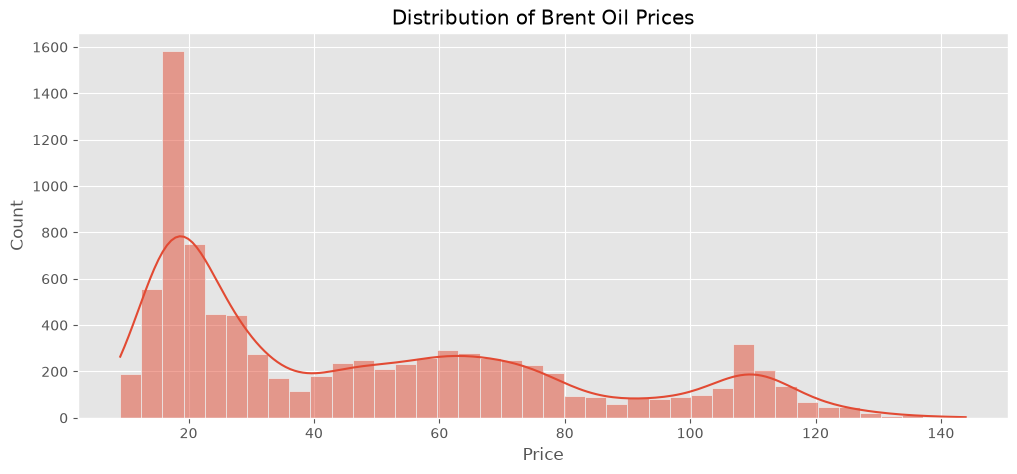

In [12]:
plt.figure(figsize=(12,5))

sns.histplot(df["Price"], bins=40, kde=True)

plt.title("Distribution of Brent Oil Prices")

plt.show()

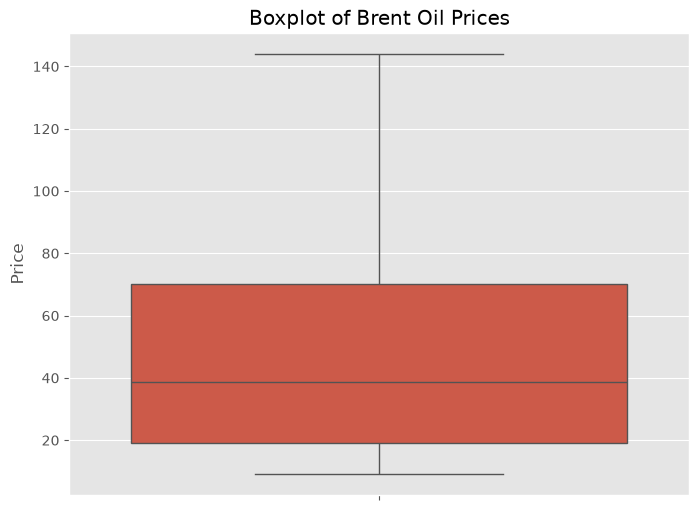

In [13]:
plt.figure(figsize=(8,6))

sns.boxplot(y=df["Price"])

plt.title("Boxplot of Brent Oil Prices")

plt.show()

## Interpretation of the Distribution and Boxplot

The histogram and boxplot provide insights into the distribution, spread, and variability of Brent oil prices over the study period.

### Distribution of Brent Oil Prices (Histogram)

The histogram shows that Brent oil prices are **not normally distributed**. Instead, the distribution is **right-skewed** and appears to have **multiple peaks (multimodal)**, indicating that prices were concentrated around several different levels over time rather than a single average value.

**Key observations:**

- A large proportion of observations are concentrated between **$15 and $30 per barrel**, representing periods of relatively low oil prices.
- Additional peaks are visible around **$60–70** and **$100–115**, suggesting different market regimes during the historical period.
- The distribution has a **long right tail**, with prices extending above **$140 per barrel**, indicating occasional periods of exceptionally high prices.
- The non-normal and multimodal nature of the distribution suggests that Brent oil prices have experienced structural changes driven by major economic and geopolitical events.

### Boxplot of Brent Oil Prices

The boxplot summarizes the spread and central tendency of Brent oil prices.

**Key observations:**

- The **median price** is approximately **$38 per barrel**, indicating that half of the observations are below this value.
- The middle 50% of the data (Interquartile Range) lies roughly between **$19 and $70 per barrel**, showing considerable variability in oil prices.
- The overall range extends from approximately **$9 to $144 per barrel**, demonstrating substantial fluctuations throughout the study period.
- The longer upper whisker indicates greater variation at higher price levels, reflecting periods of rapid price increases.
- Although there are no individual outliers displayed beyond the whiskers, the wide spread confirms that Brent oil prices exhibit significant variability over time.

### Conclusion

Both visualizations indicate that Brent oil prices have a **non-normal distribution**, **high variability**, and evidence of **multiple market regimes**. These characteristics suggest that the underlying statistical properties of the series change over time, making traditional constant-parameter models less appropriate. Consequently, **Bayesian Change Point Analysis** is a suitable approach because it can identify structural breaks and estimate how the statistical behavior of oil prices changes across different time periods.

5. Feature Engineering

In [14]:
# Extract time-based features

df["Year"] = df["Date"].dt.year

df["Month"] = df["Date"].dt.month

df["Day"] = df["Date"].dt.day

df.head()

,Date,Price,Year,Month,Day
0,1987-05-20,18.63,1987,5,20
1,1987-05-21,18.45,1987,5,21
2,1987-05-22,18.55,1987,5,22
3,1987-05-25,18.60,1987,5,25
4,1987-05-26,18.63,1987,5,26


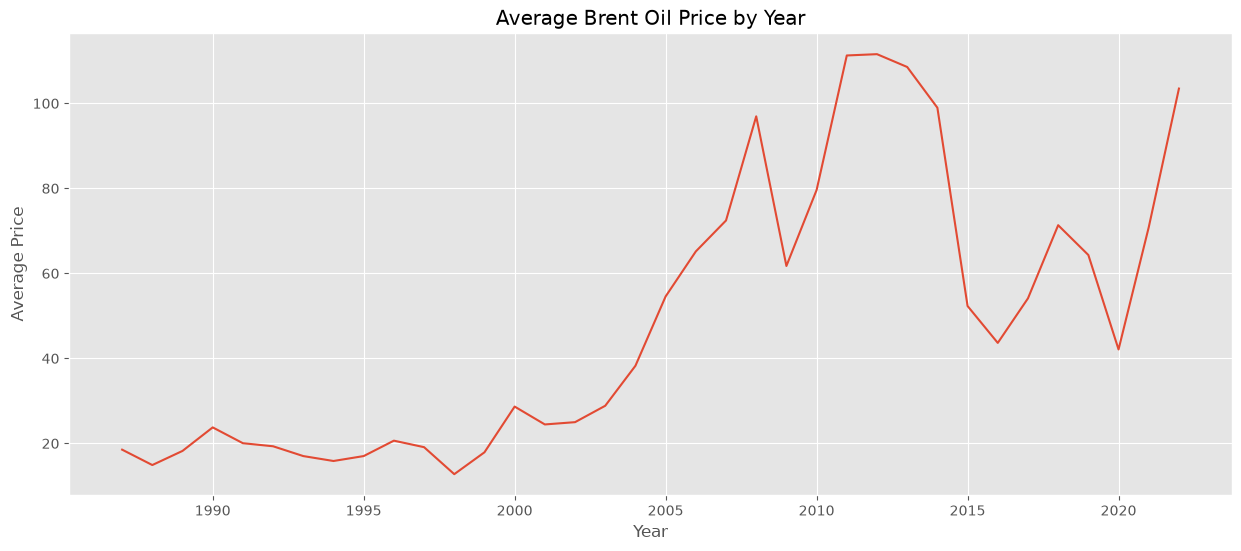

In [15]:
yearly_avg = df.groupby("Year")["Price"].mean()

plt.figure(figsize=(15,6))

yearly_avg.plot()

plt.title("Average Brent Oil Price by Year")

plt.ylabel("Average Price")

plt.show()

## Interpretation of the Average Annual Brent Oil Price

The line chart illustrates the average annual Brent oil price from **1987 to 2022**, highlighting long-term market trends and major periods of price fluctuations.

### Key Observations

- **1987–1999:** The average annual price remained relatively low and stable, generally ranging between **$15 and $25 per barrel**, indicating a period of limited price volatility.
- **2000–2008:** A clear upward trend is observed, with average prices increasing steadily from around **$28** to nearly **$97 per barrel**. This period reflects rising global oil demand and tightening supply conditions.
- **2009:** A significant decline occurred following the **2008 Global Financial Crisis**, with the annual average price dropping to approximately **$62 per barrel**, reflecting reduced global economic activity and lower oil demand.
- **2011–2013:** Brent oil prices reached their highest annual averages, remaining above **$100 per barrel** for several consecutive years. This period represents one of the strongest oil markets in the dataset.
- **2014–2016:** A sharp decline is evident, with the average price falling from around **$99** to approximately **$43 per barrel**. This decrease is consistent with increased global oil production and OPEC policy changes.
- **2017–2019:** Prices gradually recovered, reaching annual averages between **$55 and $70 per barrel**, indicating a period of market stabilization.
- **2020:** Another major decline is observed, with the average price falling to approximately **$42 per barrel** due to the COVID-19 pandemic and the resulting collapse in global oil demand.
- **2021–2022:** Oil prices recovered rapidly, with the annual average exceeding **$100 per barrel** in 2022, driven by post-pandemic economic recovery, supply constraints, and geopolitical tensions such as the Russia–Ukraine conflict.

### Conclusion

The annual average price trend demonstrates that Brent oil prices have undergone several distinct market regimes over the past three decades. The presence of prolonged upward and downward movements, along with abrupt changes associated with major global events, indicates that the time series is **non-stationary** and contains **structural breaks**. These findings support the application of **Bayesian Change Point Analysis** to identify the timing and impact of significant shifts in the oil market.